### Task 2: Using the Dataloader

In [ ]:
from torch import nn
from torch.nn import functional as F

In [ ]:
import matplotlib.pyplot as plt
import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms

from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, TensorDataset

In [ ]:
def save_checkpoint(checkpoint_path, model, optimizer):
    # state_dict: a Python dictionary object that:
    # - for a model, maps each layer to its parameter tensor;
    # - for an optimizer, contains info about the optimizer’s states and hyperparameters used.
    state = {"state_dict": model.state_dict(), "optimizer": optimizer.state_dict()}
    torch.save(state, checkpoint_path)
    print("model saved to %s" % checkpoint_path)


def load_checkpoint(checkpoint_path, model, optimizer):
    state = torch.load(checkpoint_path)
    model.load_state_dict(state["state_dict"])
    optimizer.load_state_dict(state["optimizer"])
    print("model loaded from %s" % checkpoint_path)

We can use dataloader as iterator by using iter() function.

# Putting all together

In [ ]:
import time

from IPython.display import clear_output

# use GPU if available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
default_dtype = torch.float32

device

device(type='cuda')

In [ ]:
from tqdm.auto import tqdm


def train_model(
    model, train_loader, val_loader, loss_fn, opt, n_epochs: int, device=device
):
    """
    model: nn tp train
    train_loader, val_loader: data loaders
    loss_fn: loss function to minimize
    opt: optimizer to update NN weights using gradient descent
    n_epochs: number of epochs = number of full data iterations
    """
    train_loss = []
    train_accuracy = []
    val_loss = []
    val_accuracy = []

    # TRAIN
    for epoch in tqdm(range(n_epochs)):
        ep_train_loss = []
        ep_train_accuracy = []
        ep_val_loss = []
        ep_val_accuracy = []

        start_time = time.time()
        model.train(True)  # enable dropout / batch_norm training behavior

        for X_batch, y_batch in train_loader:
            # move data to target device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            # train on batch: compute loss, calc grads, perform optimizer step and zero the grads
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            ep_train_loss.append(loss.item())

            y_pred = preds.max(-1)[1]  # YOUR CODE HERE
            ep_train_accuracy.append(
                (y_pred == y_batch).to(default_dtype).mean().item()
            )

        model.train(False)  # disable dropout / use averages for batch_norm

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                # move data to target device
                # YOUR CODE HERE
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                preds = model(X_batch)
                loss = loss_fn(preds, y_batch)
                # compute predictions
                # YOUR CODE HERE
                ep_val_loss.append(loss.item())  # YOUR CODE HERE
                y_pred = preds.max(-1)[1]  # YOUR CODE HERE
                ep_val_accuracy.append(
                    (y_pred == y_batch).to(default_dtype).mean().item()
                )  # YOUR CODE HERE

        # print the results for this epoch:
        # Print out what's happening

        # print(f"Epoch {epoch + 1} of {n_epochs} took {time.time() - start_time:.3f}s")

        train_loss.append(np.mean(ep_train_loss))
        train_accuracy.append(np.mean(ep_train_accuracy))
        val_loss.append(np.mean(ep_val_loss))
        val_accuracy.append(np.mean(ep_val_accuracy))

        if (epoch + 1) % (n_epochs / 5):
            print(
                f"Epoch: {epoch+1} | "
                f"train_loss: {train_loss[-1]:.4f} | "
                f"train_acc: {train_accuracy[-1]:.4f} | "
                f"test_loss: {val_loss[-1]:.4f} | "
                f"test_acc: {val_accuracy[-1]:.4f}"
            )

        # print(f"\t  training loss: {train_loss[-1]:.6f}")
        # print(f"\tvalidation loss: {val_loss[-1]:.6f}")
        # print(f"\tvalidation accuracy: {val_accuracy[-1]:.3f}")

    return train_loss, val_loss, train_accuracy, val_accuracy


def save_answers(model, scaller):
    # 2. Загрузка тестовых данных
    test_df = pd.read_csv("test.csv")

    # 3. Предобработка данных (как при обучении)
    # Убедитесь, что scaler был сохранен при обучении, или создайте новый
    # Здесь предполагаем, что scaler уже определен (как в вашем коде обучения)
    X_test = test_df.values  # или test_df.drop(columns=[...]) если есть лишние колонки

    # Масштабирование
    X_test_scaled = scaler.transform(
        X_test
    )  # используем тот же scaler, что и для train

    # 4. Создание DataLoader для тестовых данных
    test_data = TensorDataset(torch.FloatTensor(X_test_scaled))
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    # 5. Предсказание на тестовых данных
    predictions = []
    with torch.no_grad():
        for inputs in test_loader:
            inputs = inputs[0].to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            predictions.extend(preds.cpu().numpy())

    # 6. Сохранение результатов
    results_df = pd.DataFrame({"target": predictions})

    # Сохранение в CSV
    results_df.to_csv("answers.csv", index=False, header=False)
    print("Результаты сохранены в answers.csv")

In [ ]:
def plot_train_process(train_loss, val_loss, train_accuracy, val_accuracy):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].set_title("Loss")
    axes[0].plot(train_loss, label="train")
    axes[0].plot(val_loss, label="validation")
    axes[0].legend()

    axes[1].set_title("Validation accuracy")
    axes[1].plot(train_accuracy, label="train")
    axes[1].plot(val_accuracy, label="validation")
    axes[1].legend()

## Real network

In [ ]:
# Модель (ваша существующая архитектура)
class ImprovedNeuralNet(nn.Module):
    def __init__(self, input_size, drop_out=0.1):  # Увеличил dropout
        super(ImprovedNeuralNet, self).__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(drop_out)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(drop_out)

        self.fc3 = nn.Linear(128, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout3 = nn.Dropout(drop_out)

        self.fc4 = nn.Linear(128, 64)
        self.bn4 = nn.BatchNorm1d(64)
        self.dropout4 = nn.Dropout(drop_out)

        self.fc5 = nn.Linear(64, 2)

        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU(0.1)
        self.swish = nn.SiLU()

    def forward(self, x):
        identity = x

        x = self.fc1(x)
        x = self.bn1(x)
        x = self.swish(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.leaky_relu(x)
        x = self.dropout2(x)

        residual = x
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.dropout3(x)
        x = x + residual

        x = self.fc4(x)
        x = self.bn4(x)
        x = self.leaky_relu(x)
        x = self.dropout4(x)

        x = self.fc5(x)

        return x

Training size: 721
Validation size: 309
Test size: 258


  1%|          | 2/200 [00:00<00:10, 18.14it/s]

Epoch: 1 | train_loss: 0.7273 | train_acc: 0.5269 | test_loss: 0.6859 | test_acc: 0.6199
Epoch: 2 | train_loss: 0.7350 | train_acc: 0.5125 | test_loss: 0.6805 | test_acc: 0.6446
Epoch: 3 | train_loss: 0.7301 | train_acc: 0.5127 | test_loss: 0.6720 | test_acc: 0.6368
Epoch: 4 | train_loss: 0.7373 | train_acc: 0.5099 | test_loss: 0.6656 | test_acc: 0.6331


  4%|▎         | 7/200 [00:00<00:10, 18.97it/s]

Epoch: 5 | train_loss: 0.7122 | train_acc: 0.5427 | test_loss: 0.6559 | test_acc: 0.6785
Epoch: 6 | train_loss: 0.7013 | train_acc: 0.5581 | test_loss: 0.6490 | test_acc: 0.6821
Epoch: 7 | train_loss: 0.7268 | train_acc: 0.5269 | test_loss: 0.6431 | test_acc: 0.6967
Epoch: 8 | train_loss: 0.7097 | train_acc: 0.5658 | test_loss: 0.6379 | test_acc: 0.7182


...

 96%|█████████▌| 192/200 [00:06<00:00, 31.97it/s]

Epoch: 189 | train_loss: 0.4382 | train_acc: 0.8095 | test_loss: 0.4117 | test_acc: 0.8627
Epoch: 190 | train_loss: 0.4448 | train_acc: 0.8147 | test_loss: 0.4110 | test_acc: 0.8601
Epoch: 191 | train_loss: 0.4149 | train_acc: 0.8393 | test_loss: 0.4117 | test_acc: 0.8653
Epoch: 192 | train_loss: 0.4191 | train_acc: 0.8304 | test_loss: 0.4114 | test_acc: 0.8653
Epoch: 193 | train_loss: 0.4345 | train_acc: 0.8045 | test_loss: 0.4104 | test_acc: 0.8653
Epoch: 194 | train_loss: 0.4256 | train_acc: 0.8255 | test_loss: 0.4097 | test_acc: 0.8679
Epoch: 195 | train_loss: 0.4335 | train_acc: 0.8082 | test_loss: 0.4081 | test_acc: 0.8653


100%|██████████| 200/200 [00:07<00:00, 28.08it/s]

Epoch: 196 | train_loss: 0.4387 | train_acc: 0.8077 | test_loss: 0.4075 | test_acc: 0.8627
Epoch: 197 | train_loss: 0.4113 | train_acc: 0.8323 | test_loss: 0.4065 | test_acc: 0.8653
Epoch: 198 | train_loss: 0.4187 | train_acc: 0.8178 | test_loss: 0.4084 | test_acc: 0.8653
Epoch: 199 | train_loss: 0.4380 | train_acc: 0.8012 | test_loss: 0.4070 | test_acc: 0.8653
Epoch: 200 | train_loss: 0.4188 | train_acc: 0.8151 | test_loss: 0.4064 | test_acc: 0.8653

Test Loss: 0.3874
Test Accuracy: 0.8605
Результаты сохранены в answers.csv



/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


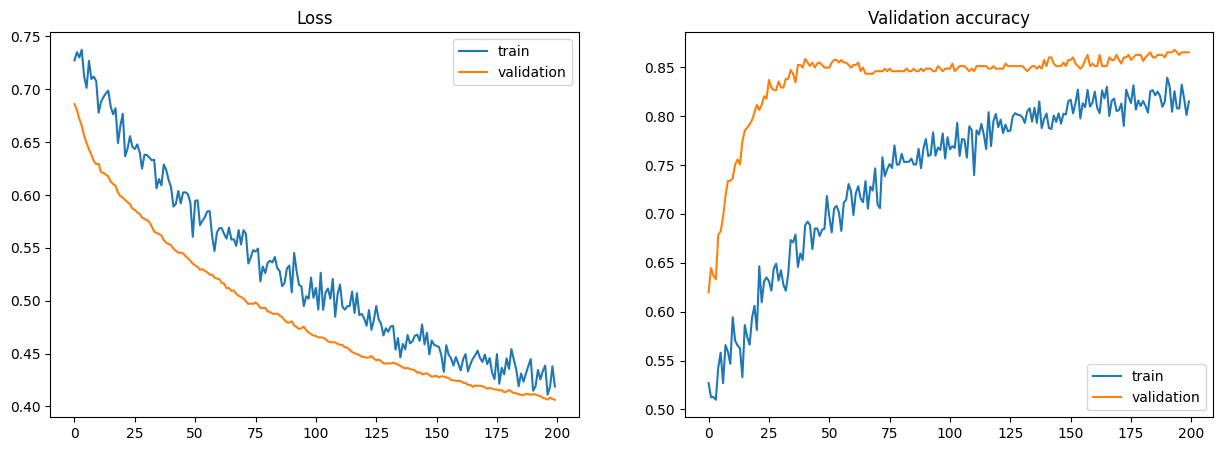

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка данных
train_df = pd.read_csv("train.csv")

# Разделение на признаки и целевую переменную
X = train_df.drop(columns=["target"])
y = train_df["target"].to_numpy()

# Разделение на train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Разделение train на train/val (75/25 от train)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

# Масштабирование данных (без утечки)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Только fit на train
X_val_scaled = scaler.transform(X_val)  # transform на val
X_test_scaled = scaler.transform(X_test)  # transform на test

# Создание Dataset и DataLoader
train_data = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train))
val_data = TensorDataset(torch.FloatTensor(X_val_scaled), torch.LongTensor(y_val))
test_data = TensorDataset(torch.FloatTensor(X_test_scaled), torch.LongTensor(y_test))

batch_size = 128
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Training size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

# Инициализация модели
input_shape = X_train.shape[1]
model = ImprovedNeuralNet(input_size=input_shape, drop_out=0.4).to(device)
# model = SimplifiedNet(input_shape)

# Функция потерь с учетом дисбаланса классов
class_counts = np.bincount(y_train)
class_weights = torch.tensor(
    [1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float32
).to(device)
loss_func = nn.CrossEntropyLoss(weight=class_weights)

# Оптимизатор с более высоким learning rate и weight decay
optimizer = optim.AdamW(model.parameters(), lr=0.000006, weight_decay=1e-2)
# optimizer = torch.optim.SGD(params=model.parameters(), lr=0.0001)

# Планировщик learning rate
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)

# Обучение
n_epochs = 200
train_loss, val_loss, train_accuracy, val_accuracy = train_model(
    model, train_loader, val_loader, loss_func, optimizer, n_epochs
)

# Оценка на тестовом наборе
model.eval()
test_correct = 0
test_total = 0
test_loss = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = loss_func(outputs, labels)

        test_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"\nTest Loss: {test_loss / len(test_loader):.4f}")
print(f"Test Accuracy: {test_correct / test_total:.4f}")
plot_train_process(train_loss, val_loss, train_accuracy, val_accuracy)

save_answers(model, scaler)

In [ ]:
assert 1 == 2

AssertionError: 

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
from collections import defaultdict

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Загрузка данных
train_df = pd.read_csv("train.csv")
X = train_df.drop(columns=["target"])
y = train_df["target"].to_numpy()

# Параметры для перебора
dropout_values = [0.35, 0.45, 0.4]
weight_decay_values = [1e-3, 1e-4, 1e-5]
class_weight_strategies = ["balanced", "inverse", "uniform"]
n_epochs = 150


# Функция для обучения модели
def train_model(model, train_loader, val_loader, loss_func, optimizer, n_epochs=100):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_func(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # Валидация
        model.eval()
        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = loss_func(outputs, labels)

                val_running_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_accuracy = val_correct / val_total
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # Сохраняем лучшую модель
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

    return best_model_state, train_losses, val_losses, train_accuracies, val_accuracies


# Кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = defaultdict(list)

for dropout in dropout_values:
    for weight_decay in weight_decay_values:
        for weight_strategy in class_weight_strategies:
            print(
                f"\nTraining with dropout={dropout}, weight_decay={weight_decay}, class_weights={weight_strategy}"
            )

            fold_results = {
                "train_loss": [],
                "val_loss": [],
                "train_acc": [],
                "val_acc": [],
            }

            for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
                print(f"\nFold {fold + 1}/5")

                # Разделение данных
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y[train_idx], y[val_idx]

                # Масштабирование
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train)
                X_val_scaled = scaler.transform(X_val)

                # Веса классов
                if weight_strategy == "balanced":
                    class_counts = np.bincount(y_train)
                    weights = torch.tensor(
                        [1.0 / class_counts[0], 1.0 / class_counts[1]],
                        dtype=torch.float32,
                    ).to(device)
                elif weight_strategy == "inverse":
                    class_counts = np.bincount(y_train)
                    weights = torch.tensor(
                        [class_counts[1] / class_counts[0], 1.0], dtype=torch.float32
                    ).to(device)
                else:  # uniform
                    weights = torch.tensor([1.0, 1.0], dtype=torch.float32).to(device)

                loss_func = nn.CrossEntropyLoss(weight=weights)

                # DataLoader
                train_data = TensorDataset(
                    torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train)
                )
                val_data = TensorDataset(
                    torch.FloatTensor(X_val_scaled), torch.LongTensor(y_val)
                )

                train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
                val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

                # Модель и оптимизатор
                model = ImprovedNeuralNet(
                    input_size=X_train.shape[1], drop_out=dropout
                ).to(device)
                optimizer = optim.AdamW(
                    model.parameters(), lr=1e-4, weight_decay=weight_decay
                )

                # Обучение
                best_model_state, train_loss, val_loss, train_acc, val_acc = (
                    train_model(
                        model,
                        train_loader,
                        val_loader,
                        loss_func,
                        optimizer,
                        n_epochs=100,
                    )
                )

                # Сохраняем результаты
                fold_results["train_loss"].append(train_loss[-1])
                fold_results["val_loss"].append(val_loss[-1])
                fold_results["train_acc"].append(train_acc[-1])
                fold_results["val_acc"].append(val_acc[-1])

            # Средние результаты по фолдам
            avg_train_loss = np.mean(fold_results["train_loss"])
            avg_val_loss = np.mean(fold_results["val_loss"])
            avg_train_acc = np.mean(fold_results["train_acc"])
            avg_val_acc = np.mean(fold_results["val_acc"])

            print(
                f"\nResults for dropout={dropout}, weight_decay={weight_decay}, class_weights={weight_strategy}:"
            )
            print(
                f"Avg Train Loss: {avg_train_loss:.4f}, Avg Val Loss: {avg_val_loss:.4f}"
            )
            print(f"Avg Train Acc: {avg_train_acc:.4f}, Avg Val Acc: {avg_val_acc:.4f}")

            # Сохраняем результаты
            results["dropout"].append(dropout)
            results["weight_decay"].append(weight_decay)
            results["class_weights"].append(weight_strategy)
            results["avg_train_loss"].append(avg_train_loss)
            results["avg_val_loss"].append(avg_val_loss)
            results["avg_train_acc"].append(avg_train_acc)
            results["avg_val_acc"].append(avg_val_acc)

# Сохраняем результаты в DataFrame
results_df = pd.DataFrame(results)
results_df.to_csv("cross_validation_results.csv", index=False)

# Находим лучшие параметры
best_idx = results_df["avg_val_acc"].idxmax()
best_params = results_df.loc[best_idx]

print("\nBest parameters found:")
print(best_params)

# Обучаем финальную модель на всех данных с лучшими параметрами
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Веса классов для лучшей модели
if best_params["class_weights"] == "balanced":
    class_counts = np.bincount(y)
    weights = torch.tensor(
        [1.0 / class_counts[0], 1.0 / class_counts[1]], dtype=torch.float32
    ).to(device)
elif best_params["class_weights"] == "inverse":
    class_counts = np.bincount(y)
    weights = torch.tensor(
        [class_counts[1] / class_counts[0], 1.0], dtype=torch.float32
    ).to(device)
else:
    weights = torch.tensor([1.0, 1.0], dtype=torch.float32).to(device)

final_model = ImprovedNeuralNet(
    input_size=X.shape[1], drop_out=best_params["dropout"]
).to(device)

optimizer = optim.AdamW(
    final_model.parameters(), lr=1e-4, weight_decay=best_params["weight_decay"]
)

loss_func = nn.CrossEntropyLoss(weight=weights)

# Создаем DataLoader для всех данных
full_data = TensorDataset(torch.FloatTensor(X_scaled), torch.LongTensor(y))
full_loader = DataLoader(full_data, batch_size=32, shuffle=True)

# Обучаем финальную модель
best_model_state, _, _, _, _ = train_model(
    final_model, full_loader, full_loader, loss_func, optimizer, n_epochs=150
)
final_model.load_state_dict(best_model_state)

# Сохраняем финальную модель и scaler
torch.save(final_model.state_dict(), "best_model.pth")
torch.save(scaler, "scaler.pth")

In [ ]:
def save_answers_clf(clf, scaller):
    # 2. Загрузка тестовых данных
    test_df = pd.read_csv("test.csv")

    # 3. Предобработка данных (как при обучении)
    # Убедитесь, что scaler был сохранен при обучении, или создайте новый
    # Здесь предполагаем, что scaler уже определен (как в вашем коде обучения)
    X_test = test_df.values  # или test_df.drop(columns=[...]) если есть лишние колонки

    # Масштабирование
    X_test_scaled = scaler.transform(
        X_test
    )  # используем тот же scaler, что и для train

    # 4. Создание DataLoader для тестовых данных
    test_data = TensorDataset(torch.FloatTensor(X_test_scaled))
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    # 5. Предсказание на тестовых данных
    predictions = []
    predictions = clf.predict(X_test_scaled)

    # 6. Сохранение результатов
    results_df = pd.DataFrame({"target": predictions})

    # Сохранение в CSV
    results_df.to_csv("answers_tbnt.csv", index=False, header=False)
    print("Результаты сохранены в answers.csv")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from pytorch_tabnet.tab_model import TabNetClassifier

# Загрузка данных (пример для датасета фисташек)
data = pd.read_csv(
    "train.csv"
)  # Предположим, колонка 'Class' содержит метки ('Kirmizi', 'Siirt')

# Предобработка
X = data.drop(columns=["target"])  # Все признаки кроме целевой
y = LabelEncoder().fit_transform(data["target"])  # Кодируем метки в 0 и 1

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование числовых признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Инициализация TabNet
# tabnet = TabNetClassifier(
#     n_d=64,                   # Размерность слоя предсказания
#     n_a=64,                   # Размерность слоя внимания
#     n_steps=5,                # Количество шагов итераций
#     gamma=1.3,                # Коэффициент масштабирования для шага
#     optimizer_params=dict(lr=2e-2, weight_decay=1e-5),
#     scheduler_params={"step_size": 10, "gamma": 0.9},
#     mask_type="entmax"        # Тип маски ('sparsemax' или 'entmax')
# )

tabnet = TabNetClassifier(
    n_d=32,  # Уменьшите для меньшего датасета
    n_a=32,  # Аналогично n_d
    n_steps=3,  # Упростите архитектуру
    gamma=1.2,  # Уменьшите для более плавного обучения
    optimizer_params=dict(lr=1e-2, weight_decay=1e-4),  # Уменьшите lr
    scheduler_params={"step_size": 5, "gamma": 0.8},  # Более агрессивное снижение lr
    mask_type="entmax",  # Используйте "sparsemax" для более жёсткого выбора признаков
)

# Обучение
tabnet.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=100,  # Максимум эпох
    patience=15,  # Ранняя остановка, если нет улучшений
    batch_size=32,  # Размер батча
    virtual_batch_size=16,  # Виртуальный батч для экономии памяти
    drop_last=False,
)

# Предсказание
y_pred = tabnet.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

# Важность признаков
feature_importances = tabnet.feature_importances_
print("Важность признаков:", dict(zip(data.columns[:-1], feature_importances)))

save_answers_clf(tabnet, scaler)

In [ ]:
import numpy as np
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# Определяем сетку параметров
param_grid = {
    "n_d": [8, 16, 24],  # Размерность слоя предсказания
    "n_a": [8, 16, 24],  # Размерность слоя внимания
    "lr": [0.01, 0.02, 0.005],  # Learning rate
    "n_steps": [3, 4],  # Количество шагов итераций
}

# Лучшие параметры и точность
best_params = {}
best_accuracy = 0

# Перебор всех комбинаций
for n_d in tqdm(param_grid["n_d"], desc="n_d"):
    for n_a in tqdm(param_grid["n_a"], desc="n_a", leave=False):
        for lr in tqdm(param_grid["lr"], desc="lr", leave=False):
            for n_steps in tqdm(param_grid["n_steps"], desc="n_steps", leave=False):

                # Инициализация модели с текущими параметрами
                tabnet = TabNetClassifier(
                    n_d=n_d,
                    n_a=n_a,
                    n_steps=n_steps,
                    optimizer_params=dict(lr=lr),
                    scheduler_params={"step_size": 10, "gamma": 0.9},
                    mask_type="sparsemax",
                )

                # Обучение
                tabnet.fit(
                    X_train,
                    y_train,
                    eval_set=[(X_test, y_test)],
                    eval_metric=["accuracy"],
                    max_epochs=50,
                    patience=20,
                    batch_size=64,
                    # verbose=0  # Отключаем вывод в консоль
                )

                # Оценка точности
                y_pred = tabnet.predict(X_test)
                acc = accuracy_score(y_test, y_pred)

                # Сохранение лучших параметров
                if acc > best_accuracy:
                    best_accuracy = acc
                    best_params = {"n_d": n_d, "n_a": n_a, "lr": lr, "n_steps": n_steps}
                    print(f"New best: {best_params} | Accuracy: {best_accuracy:.4f}")

# Вывод лучших параметров
print("\nBest parameters found:")
print(best_params)
print(f"Best validation accuracy: {best_accuracy:.4f}")